# Voice under Stress - Analysis

import of all functions needed

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import scipy 
import math

#Stats
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.stats.descriptivestats import sign_test
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.multivariate.manova import MANOVA 
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

#Figures
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams


In [2]:
homepath=os.getcwd()
scripts_path=os.path.join(homepath, 'scripts')
sys.path.append(scripts_path)
import myml
import mystress
import myvoice

## Settings

In [ ]:
# Check version of Python==64
!python -c "import sys; print(sys.maxsize > 2**32)"

# random seed for reproducability
np.random.seed(42)

# show all columns of dataframes
pd.set_option('display.max_columns', None)

# set current dir to highest hierachy to add data path
os.chdir('/')
data_folder='/data'
sys.path.append(data_folder)
os.chdir(homepath)

True


# Main Code

### Functions for Figures

In [4]:
def bar_cond(df, dv, group, subgroup, label):
    sns.set(context="paper", palette="bwr", style="ticks")
    ax=sns.violinplot(y=dv, x=group, palette={0: "white", 1: "#B7B7B7"}, hue=subgroup,
                      data=df)  
    plt.show()
    
def swarm_dualplot(df, dv, group, subgroup, label):
    """draws boxplots plus datapoints"""
    plt.figure(figsize=(8,4))
    sns.set(context="paper", style='whitegrid')
    ax = sns.boxplot(x=group, y=dv, data=df, hue='Cond', showfliers = False, color='grey')
    sns.swarmplot(x=group, y=dv, data=df, hue='Cond', dodge=True, ax=ax)
    plt.savefig('swarmplot_' + label + '.png', format='png', dpi=1200)
    plt.show()
    
def vpn_plots(df):
    """scatterplots with vpn-numbers as labels"""
    types = df.vpn
    y_coords = df_vpn.PANA_Delta_NA 
    x_coords = df_vpn.Cond #

    for i,type in enumerate(types):
        x = x_coords[i]
        y = y_coords[i]
        plt.scatter(x, y, marker='x', color='red')
        plt.text(x+0.01, y+0.01, type, fontsize=20)
    plt.show() 

### Statistical Functions

In [5]:
def eta_squared(aov):
    aov['eta_sq'] = 'NaN'
    aov['eta_sq'] = aov[:-1]['sum_sq']/sum(aov['sum_sq'])
    return aov

def omega_squared(aov):
    mse = aov['sum_sq'][-1]/aov['df'][-1]
    aov['omega_sq'] = 'NaN'
    aov['omega_sq'] = (aov[:-1]['sum_sq']-(aov[:-1]['df']*mse))/(sum(aov['sum_sq'])+mse)
    return aov

### Step 0: Re-run Sound-Preprocessing

In [6]:
#rerun_soundprep()

If you want to completely reanalyze all sound data, run: **rerun_soundprep()**

### Step 1: load data and calculate variables

In [7]:
filename_librosa='./processed/features.csv'
filename_behavior=data_folder + '/raw/TSST_behavior.csv'
filename_praat='./processed/new_praat_results'
filename_opensmile='./processed/opensmile_features.csv'
filename_output='./processed/final_df.csv'

In [ ]:
df, librosa_featurenames, praat_featurenames, opensimle_feature=mystress.load_df(filename_opensmile, filename_praat, 
                                                 filename_librosa, filename_behavior, filename_output)

In [ ]:
df=mystress.calc_var(df)

In [11]:
audio=praat_featurenames + list(opensimle_feature)+librosa_featurenames

### Step 2: Check the Dataset

In [12]:
df[audio].describe(include = 'all')

,meanF0Hz,stdevF0Hz,HNR,localJitter,localabsoluteJitter,rapJitter,ppq5Jitter,ddpJitter,localShimmer,localdbShimmer,apq3Shimmer,apq5Shimmer,apq11Shimmer,ddaShimmer,median_pitch,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,loudness_sma3_amean,loudness_sma3_stddevNorm,loudness_sma3_percentile20.0,loudness_sma3_percentile50.0,loudness_sma3_percentile80.0,loudness_sma3_pctlrange0-2,loudness_sma3_meanRisingSlope,loudness_sma3_stddevRisingSlope,loudness_sma3_meanFallingSlope,loudness_sma3_stddevFallingSlope,spectralFlux_sma3_amean,spectralFlux_sma3_stddevNorm,mfcc1_sma3_amean,mfcc1_sma3_stddevNorm,mfcc2_sma3_amean,mfcc2_sma3_stddevNorm,mfcc3_sma3_amean,mfcc3_sma3_stddevNorm,mfcc4_sma3_amean,mfcc4_sma3_stddevNorm,jitterLocal_sma3nz_amean,jitterLocal_sma3nz_stddevNorm,shimmerLocaldB_sma3nz_amean,shimmerLocaldB_sma3nz_stddevNorm,HNRdBACF_sma3nz_amean,HNRdBACF_sma3nz_stddevNorm,logRelF0-H1-H2_sma3nz_amean,logRelF0-H1-H2_sma3nz_stddevNorm,logRelF0-H1-A3_sma3nz_amean,logRelF0-H1-A3_sma3nz_stddevNorm,F1frequency_sma3nz_amean,F1frequency_sma3nz_stddevNorm,F1bandwidth_sma3nz_amean,F1bandwidth_sma3nz_stddevNorm,F1amplitudeLogRelF0_sma3nz_amean,F1amplitudeLogRelF0_sma3nz_stddevNorm,F2frequency_sma3nz_amean,F2frequency_sma3nz_stddevNorm,F2bandwidth_sma3nz_amean,F2bandwidth_sma3nz_stddevNorm,F2amplitudeLogRelF0_sma3nz_amean,F2amplitudeLogRelF0_sma3nz_stddevNorm,F3frequency_sma3nz_amean,F3frequency_sma3nz_stddevNorm,F3bandwidth_sma3nz_amean,F3bandwidth_sma3nz_stddevNorm,F3amplitudeLogRelF0_sma3nz_amean,F3amplitudeLogRelF0_sma3nz_stddevNorm,alphaRatioV_sma3nz_amean,alphaRatioV_sma3nz_stddevNorm,hammarbergIndexV_sma3nz_amean,hammarbergIndexV_sma3nz_stddevNorm,slopeV0-500_sma3nz_amean,slopeV0-500_sma3nz_stddevNorm,slopeV500-1500_sma3nz_amean,slopeV500-1500_sma3nz_stddevNorm,spectralFluxV_sma3nz_amean,spectralFluxV_sma3nz_stddevNorm,mfcc1V_sma3nz_amean,mfcc1V_sma3nz_stddevNorm,mfcc2V_sma3nz_amean,mfcc2V_sma3nz_stddevNorm,mfcc3V_sma3nz_amean,mfcc3V_sma3nz_stddevNorm,mfcc4V_sma3nz_amean,mfcc4V_sma3nz_stddevNorm,alphaRatioUV_sma3nz_amean,hammarbergIndexUV_sma3nz_amean,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,spectrum_0,spectrum_1,spectrum_2,spectrum_3,spectrum_4,spectrum_5,spectrum_6,spectrum_7,spectrum_8,spectrum_9,spectrum_10,spectrum_11,spectrum_12,spectrum_13,spectrum_14,spectrum_15,spectrum_16,spectrum_17,spectrum_18,spectrum_19,spectrum_20,spectrum_21,spectrum_22,spectrum_23,spectrum_24,spectrum_25,spectrum_26,spectrum_27,spectrum_28,spectrum_29,spectrum_30,spectrum_31,spectrum_32,spectrum_33,spectrum_34,spectrum_35,spectrum_36,spectrum_37,spectrum_38,spectrum_39,energy,length
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0

[[ go back to the top ]](#Table-of-contents)


### Step 3: Stress Induction (Group Comparison)

Here we compute the descriptive statistics of age and BMI for the entire sample.

In [13]:
# entire sample age and bmi

col_of_interest = ['Age', 'BMI']
df[col_of_interest].describe(include='all')

,Age,BMI
count,50.000000,42.000000
mean,23.240000,23.283095
std,3.920433,2.345921
min,18.000000,18.940000
25%,20.000000,21.337500
50%,22.000000,23.220000
75%,26.750000,24.457500
max,34.000000,28.070000


Here we compute the same descriptives split by condition (0 = fTSST, 1 = TSST).

In [14]:
# split by condition for age and bmi
# Cond 0 = fTSST, Cond 1 = TSST

col_of_interest=['Age', 'BMI']
df.groupby('Cond')[col_of_interest].describe(include = 'all')

Age                                                  BMI             \
     count   mean       std   min   25%   50%   75%   max count       mean   
Cond                                                                         
0     25.0  24.00  4.272002  18.0  20.0  24.0  27.0  32.0  21.0  23.269524   
1     25.0  22.48  3.453501  19.0  21.0  21.0  23.0  34.0  21.0  23.296667   

                                                   
           std    min    25%    50%    75%    max  
Cond                                               
0     1.895665  21.08  21.60  23.29  24.15  28.07  
1     2.772710  18.94  20.81  23.15  24.76  27.78

Here we compute the sex distribution of the entire sample (1 = female).

In [15]:
# entire sample for sex

sex_total = pd.DataFrame([df['Sex'].agg(
    n='count',
    n_female=lambda s: (s == 1).sum(),
    pct_female=lambda s: 100 * (s == 1).mean()
)], index=['Total']).round({'pct_female': 1})
sex_total

,n,n_female,pct_female
Total,50.0,23.0,46.0


Here we compute the sex distribution split by condition.

In [16]:
# split by condition for sex
# Cond 0 = fTSST, Cond 1 = TSST

sex_by_cond = df.groupby('Cond')['Sex'].agg(
    n='count',
    n_female=lambda s: (s == 1).sum(),
    pct_female=lambda s: 100 * (s == 1).mean()
).round({'pct_female': 1})
sex_by_cond

,n,n_female,pct_female
Cond,,,
0,25,11,44.0
1,25,12,48.0


Here we compute the menstrual-cycle phase distribution of the female participants, as counts and as row percentages (1 = follicular, 2 = ovulation, 3 = luteal).

In [17]:
# entire (female) sample for hormone status
# 1 = follicular, 2 = ovulation, 3 = luteal

cycle_by_cond = pd.crosstab(df['Cond'], df['cycle_phase'], dropna=False)
cycle_by_cond

cycle_by_cond_pct = (pd.crosstab(df['Cond'], df['cycle_phase'], normalize='index', dropna=False) * 100).round(1)
cycle_by_cond_pct

cycle_phase,1.0,2.0,3.0,NaN
Cond,,,,
0,28.0,4.0,8.0,60.0
1,20.0,8.0,20.0,52.0


Here we compute the cycle-phase distribution split by condition (row percentages).

In [18]:
# split by condition (females) for hormone status
# 1 = follicular, 2 = ovulation, 3 = luteal

cycle_by_cond_pct = (pd.crosstab(df['Cond'], df['cycle_phase'], normalize='index', dropna=False) * 100).round(1)
cycle_by_cond_pct

cycle_phase,1.0,2.0,3.0,NaN
Cond,,,,
0,28.0,4.0,8.0,60.0
1,20.0,8.0,20.0,52.0


Here we compute the descriptive statistics of the cortisol, sAA and negative-affect stress markers per condition.

In [19]:
col_of_interest=['Cortisol_MinMax', 'Cortisol_React', 'Delta_LNCort', 'LNco_AUCi', 'Delta_NA']
df.groupby('Cond')[col_of_interest].describe(include = 'all')

Cortisol_MinMax                                                          \
               count      mean       std   min       25%       50%       75%   
Cond                                                                           
0               25.0  2.315891  2.116052  0.09  1.041766  1.809505  2.700000   
1               25.0  6.050480  5.852318  0.47  2.187569  3.695000  8.453026   

             Cortisol_React                                                    \
         max          count      mean       std  min  25%       50%       75%   
Cond                                                                            
0     10.155           25.0  0.766754  2.299566  0.0  0.0  0.000000  0.000000   
1     22.830           25.0  5.001226  6.568774  0.0  0.0  1.345517  8.453026   

             Delta_LNCort                                                    \
         max        count      mean       std       min       25%       50%   
Cond                                                                          
0     10.155         25.0 -0.141922  0.241584 -0.451756 -0.274281 -0.189774   
1     22.830         25.0  0.306287  0.590997 -0.434520 -0.179691  0.162147   

                        LNco_AUCi                                            \
           75%      max     count      mean        std        min       25%   
Cond                                                                          
0    -0.104660  0.72618      25.0 -2.583907   6.370622 -10.031060 -6.233587   
1     0.703392  1.43876      25.0  6.725031  12.533877 -10.785228 -3.281408   

                                     Delta_NA                                  \
           50%        75%        max    count  mean       std   min  25%  50%   
Cond                                                                            
0    -4.019934  -1.878887  20.179272     25.0 -2.12  4.576389 -18.0 -2.0 -1.0   
1     3.008598  15.580684  30.220781     25.0  3.04  4.036087  -2.0  0.0  2.0   

                 
      75%   max  
Cond             
0     0.0   4.0  
1     5.0  14.0

## Stress response: figures

Here we visualise the cortisol stress response (AUCi, log-cortisol change and cortisol reaction) as combined box-/swarm-plots, split by sex and condition.

/tmp/ipykernel_2963108/3290753908.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  ax = sns.boxplot(x=group, y=dv, data=df, hue='Cond', showfliers = False, color='grey')


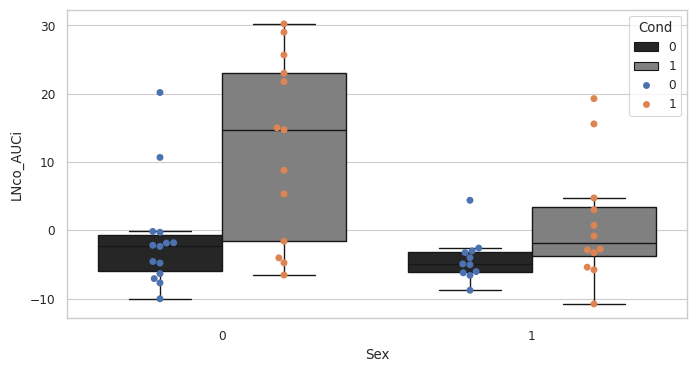

In [20]:
swarm_dualplot(df, 'LNco_AUCi', 'Sex', 'Cond', 'LNco_AUCi')

/tmp/ipykernel_2963108/3290753908.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  ax = sns.boxplot(x=group, y=dv, data=df, hue='Cond', showfliers = False, color='grey')


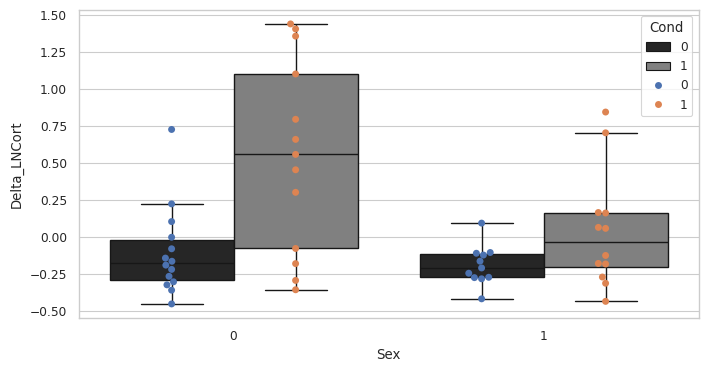

In [21]:
swarm_dualplot(df, 'Delta_LNCort', 'Sex', 'Cond', 'Delta_LNCort')

/tmp/ipykernel_2963108/3290753908.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  ax = sns.boxplot(x=group, y=dv, data=df, hue='Cond', showfliers = False, color='grey')


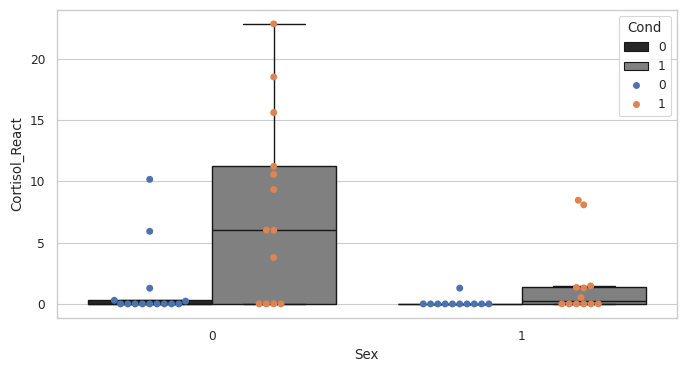

In [22]:
swarm_dualplot(df, 'Cortisol_React', 'Sex', 'Cond', 'Cortisol_MinMax')

## Group differences in the stress markers

For each stress marker we fit a two-way model with Condition, Sex and their interaction (`marker ~ C(Cond) + C(Sex) + C(Cond):C(Sex)`).

We start with the cortisol reaction.

In [23]:
formula = 'Cortisol_React ~ C(Cond) + C(Sex)+ C(Cond): C(Sex)'
model = ols(formula, df).fit()
print (model.summary())

                            OLS Regression Results                            
Dep. Variable:         Cortisol_React   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     7.970
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           0.000220
Time:                        11:29:01   Log-Likelihood:                -143.55
No. Observations:                  50   AIC:                             295.1
Df Residuals:                      46   BIC:                             302.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Same model for the salivary alpha-amylase (sAA) reaction.

In [24]:
# Hier für sAA
formula = 'sAA_React ~ C(Cond) + C(Sex) + C(Cond):C(Sex)'
model = ols(formula, df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              sAA_React   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     2.457
Date:                Sat, 20 Jun 2026   Prob (F-statistic):             0.0748
Time:                        11:29:01   Log-Likelihood:                -260.65
No. Observations:                  50   AIC:                             529.3
Df Residuals:                      46   BIC:                             536.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Same model for negative affect (PANAS).

In [25]:
# Hier für PANAS - NEGATIVE
formula = 'PANA_Delta_NA ~ C(Cond) + C(Sex) + C(Cond):C(Sex)'
model = ols(formula, df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          PANA_Delta_NA   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     7.557
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           0.000327
Time:                        11:29:01   Log-Likelihood:                -140.93
No. Observations:                  50   AIC:                             289.9
Df Residuals:                      46   BIC:                             297.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Same model for positive affect (PANAS).

In [26]:
# Hier für PANAS - POSITIVE
formula = 'PANA_Delta_PA ~ C(Cond) + C(Sex) + C(Cond):C(Sex)'
model = ols(formula, df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          PANA_Delta_PA   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     3.353
Date:                Sat, 20 Jun 2026   Prob (F-statistic):             0.0268
Time:                        11:29:01   Log-Likelihood:                -150.41
No. Observations:                  50   AIC:                             308.8
Df Residuals:                      46   BIC:                             316.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Checking the model assumptions

Here we test the four models for heteroskedasticity using the Breusch–Pagan and White tests.

In [27]:
# test for heteroskedacity

formulas = {
    "Cortisol_React": "Cortisol_React ~ C(Cond) + C(Sex) + C(Cond):C(Sex)",
    "sAA_React": "sAA_React ~ C(Cond) + C(Sex) + C(Cond):C(Sex)",
    "PANA_Delta_NA": "PANA_Delta_NA ~ C(Cond) + C(Sex) + C(Cond):C(Sex)",
    "PANA_Delta_PA": "PANA_Delta_PA ~ C(Cond) + C(Sex) + C(Cond):C(Sex)",
}

rows = []
for name, f in formulas.items():
    res = smf.ols(f, data=df).fit()
    bp = het_breuschpagan(res.resid, res.model.exog)
    wt = het_white(res.resid, res.model.exog)
    rows.append({
        "model": name,
        "BP_p_LM": bp[1],
        "BP_p_F":  bp[3],
        "White_p_LM": wt[1],
        "White_p_F":  wt[3],
    })

het_tests = pd.DataFrame(rows).set_index("model")
het_tests

,BP_p_LM,BP_p_F,White_p_LM,White_p_F
model,,,,
Cortisol_React,0.002239,0.001138,0.002239,0.001138
sAA_React,0.070361,0.069875,0.070361,0.069875
PANA_Delta_NA,0.506235,0.527707,0.506235,0.527707
PANA_Delta_PA,0.474782,0.495955,0.474782,0.495955


Since heteroskedasticity was found for cortisol (and sAA is trending in the same direction), we recompute the cortisol model with HC3 robust standard errors.

In [65]:
# since heteroskedacity was found for cortisol and sAA is trending there too, we compute hc3 robust errors

formulas = {
    "Cortisol_React": "Cortisol_React ~ C(Cond) + C(Sex) + C(Cond):C(Sex)",
    "sAA_React": "sAA_React ~ C(Cond) + C(Sex) + C(Cond):C(Sex)",
    "PANA_Delta_NA": "PANA_Delta_NA ~ C(Cond) + C(Sex) + C(Cond):C(Sex)",
    "PANA_Delta_PA": "PANA_Delta_PA ~ C(Cond) + C(Sex) + C(Cond):C(Sex)",
}

res = smf.ols(formulas["Cortisol_React"], data=df).fit()
res_hc3 = res.get_robustcov_results(cov_type="HC3")
print(res_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:         Cortisol_React   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     5.876
Date:                Sat, 20 Jun 2026   Prob (F-statistic):            0.00175
Time:                        12:14:05   Log-Likelihood:                -143.55
No. Observations:                  50   AIC:                             295.1
Df Residuals:                      46   BIC:                             302.7
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Here we compare the classical and the HC3-robust p-value for the condition effect on cortisol.

In [29]:
f = "Cortisol_React ~ C(Cond) + C(Sex) + C(Cond):C(Sex)"
m = smf.ols(f, data=df).fit()

m_hc3 = m.get_robustcov_results(cov_type="HC3")
p_hc3 = pd.Series(m_hc3.pvalues, index=m.params.index)

term = "C(Cond)[T.1]"
print("Classical p(Cond):", m.pvalues[term])
print("HC3 p(Cond):      ", p_hc3[term])

Classical p(Cond): 0.0002989274238974592
HC3 p(Cond):       0.006202402171227447


HC3 robust model for the sAA reaction.

In [66]:
res = smf.ols(formulas["sAA_React"], data=df).fit()
res_hc3 = res.get_robustcov_results(cov_type="HC3")
print(res_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:              sAA_React   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     1.578
Date:                Sat, 20 Jun 2026   Prob (F-statistic):              0.207
Time:                        12:14:16   Log-Likelihood:                -260.65
No. Observations:                  50   AIC:                             529.3
Df Residuals:                      46   BIC:                             536.9
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Classical vs. HC3-robust p-value for the condition effect on sAA.

In [31]:
f = "sAA_React ~ C(Cond) + C(Sex) + C(Cond):C(Sex)"
m = smf.ols(f, data=df).fit()

m_hc3 = m.get_robustcov_results(cov_type="HC3")
p_hc3 = pd.Series(m_hc3.pvalues, index=m.params.index)

term = "C(Cond)[T.1]"
print("Classical p(Cond):", m.pvalues[term])
print("HC3 p(Cond):      ", p_hc3[term])

Classical p(Cond): 0.03226178605217606
HC3 p(Cond):       0.09490003831382925


HC3 robust model for negative affect.

In [67]:
res = smf.ols(formulas["PANA_Delta_NA"], data=df).fit()
res_hc3 = res.get_robustcov_results(cov_type="HC3")
print(res_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:          PANA_Delta_NA   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     6.722
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           0.000742
Time:                        12:14:24   Log-Likelihood:                -140.93
No. Observations:                  50   AIC:                             289.9
Df Residuals:                      46   BIC:                             297.5
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Classical vs. HC3-robust p-value for negative affect.

In [33]:
f = "PANA_Delta_NA ~ C(Cond) + C(Sex) + C(Cond):C(Sex)"
m = smf.ols(f, data=df).fit()

m_hc3 = m.get_robustcov_results(cov_type="HC3")
p_hc3 = pd.Series(m_hc3.pvalues, index=m.params.index)

term = "C(Cond)[T.1]"
print("Classical p(Cond):", m.pvalues[term])
print("HC3 p(Cond):      ", p_hc3[term])

Classical p(Cond): 0.018883377072749237
HC3 p(Cond):       0.0018882591552774417


HC3 robust model for positive affect.

In [64]:
res = smf.ols(formulas["PANA_Delta_PA"], data=df).fit()
res_hc3 = res.get_robustcov_results(cov_type="HC3")
print(res_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:          PANA_Delta_PA   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     3.000
Date:                Sat, 20 Jun 2026   Prob (F-statistic):             0.0401
Time:                        12:13:49   Log-Likelihood:                -150.41
No. Observations:                  50   AIC:                             308.8
Df Residuals:                      46   BIC:                             316.5
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Classical vs. HC3-robust p-value for positive affect.

In [35]:
f = "PANA_Delta_PA ~ C(Cond) + C(Sex) + C(Cond):C(Sex)"
m = smf.ols(f, data=df).fit()

m_hc3 = m.get_robustcov_results(cov_type="HC3")
p_hc3 = pd.Series(m_hc3.pvalues, index=m.params.index)

term = "C(Cond)[T.1]"
print("Classical p(Cond):", m.pvalues[term])
print("HC3 p(Cond):      ", p_hc3[term])

Classical p(Cond): 0.06502533181964565
HC3 p(Cond):       0.025876203968531235


### Time course (cortisol/sAA) significance testing ###

Here we fit a linear mixed model of the log-cortisol time course (Baseline, +1 min, +20 min) with Time × Condition × Sex as fixed effects and a random intercept per participant.

In [36]:
# for cortisol

long = pd.melt(
    df, id_vars=["vpn","Cond","Sex"],
    value_vars=["LNCortisol_BL","LNCortisol_post1","LNCortisol_post20"],
    var_name="Time", value_name="LNCortisol"
)

long["Time"] = long["Time"].map({
    "LNCortisol_BL":"Baseline",
    "LNCortisol_post1":"post1",
    "LNCortisol_post20":"post20"
})

m = smf.mixedlm("LNCortisol ~ C(Time)*C(Cond)*C(Sex)", long, groups=long["vpn"])
res = m.fit(reml=False)
print(res.summary())

                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          LNCortisol
No. Observations:            150              Method:                      ML        
No. Groups:                  50               Scale:                       0.0461    
Min. group size:             3                Log-Likelihood:              -39.0656  
Max. group size:             3                Converged:                   Yes       
Mean group size:             3.0                                                     
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   1.996    0.114 17.551 0.000  1.773  2.219
C(Time)[T.post1]                           -0.019    0.081 -0.230 0.818 -0.178

Here we fit the same linear mixed model for the log-sAA time course.

In [37]:
# for sAA

long = pd.melt(
    df, id_vars=["vpn","Cond","Sex"],
    value_vars=["LNsAA_BL","LNsAA_post1","LNsAA_post20"],
    var_name="Time", value_name="LNsAA"
)

long["Time"] = long["Time"].map({
    "LNsAA_BL":"Baseline",
    "LNsAA_post1":"post1",
    "LNsAA_post20":"post20"
})

m = smf.mixedlm("LNsAA ~ C(Time)*C(Cond)*C(Sex)", long, groups=long["vpn"])
res = m.fit(reml=False)
print(res.summary())

                        Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           LNsAA   
No. Observations:            150               Method:                       ML      
No. Groups:                  50                Scale:                        0.0389  
Min. group size:             3                 Log-Likelihood:               -63.0418
Max. group size:             3                 Converged:                    Yes     
Mean group size:             3.0                                                     
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   4.515    0.203 22.259 0.000  4.117  4.912
C(Time)[T.post1]                            0.348    0.075  4.668 0.000  0.202

Here we plot the mean (± SE) log-cortisol and log-sAA time courses by condition, separately for each sex.

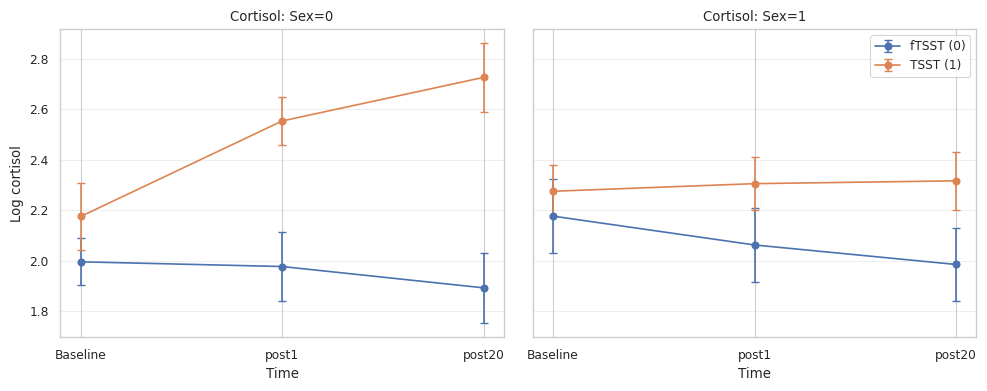

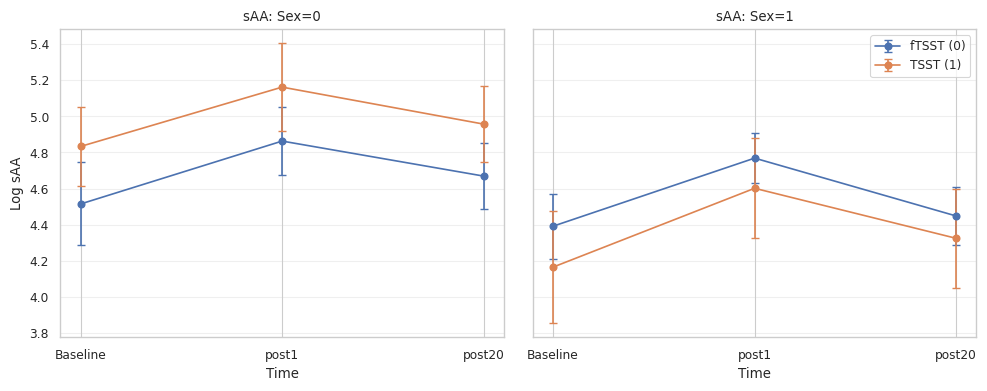

In [38]:
# graph for the time course of cortisol and sAA (LN)

def _make_long(df, value_cols, value_name):
    long = pd.melt(
        df,
        id_vars=["vpn", "Cond", "Sex"],
        value_vars=value_cols,
        var_name="Time",
        value_name=value_name
    )

    time_map = {
        value_cols[0]: "Baseline",
        value_cols[1]: "post1",
        value_cols[2]: "post20",
    }
    long["Time"] = long["Time"].map(time_map)
    long["Time"] = pd.Categorical(long["Time"], categories=["Baseline", "post1", "post20"], ordered=True)
    return long

def _summarize(long, ycol):
    g = long.groupby(["Sex", "Cond", "Time"])[ycol]
    summary = g.agg(mean="mean", sd="std", n="count").reset_index()
    summary["se"] = summary["sd"] / np.sqrt(summary["n"])
    return summary

def plot_timecourse(summary, y_label, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    for ax, sex_val in zip(axes, [0, 1]):
        sub = summary[summary["Sex"] == sex_val].copy()

        for cond_val, cond_name in [(0, "fTSST (0)"), (1, "TSST (1)")]:
            s = sub[sub["Cond"] == cond_val].sort_values("Time")
            ax.errorbar(
                s["Time"].astype(str),
                s["mean"],
                yerr=s["se"],
                marker="o",
                capsize=3,
                label=cond_name
            )

        ax.set_title(f"{title_prefix}Sex={sex_val}")
        ax.set_xlabel("Time")
        ax.grid(True, axis="y", alpha=0.3)

    axes[0].set_ylabel(y_label)
    axes[1].legend(loc="best")

    fig.tight_layout()
    plt.show()

# --- 1) Log cortisol ---
cort_long = _make_long(df, ["LNCortisol_BL", "LNCortisol_post1", "LNCortisol_post20"], "LNCortisol")
cort_sum = _summarize(cort_long, "LNCortisol")
plot_timecourse(cort_sum, y_label="Log cortisol", title_prefix="Cortisol: ")

# --- 2) Log sAA ---
saa_long = _make_long(df, ["LNsAA_BL", "LNsAA_post1", "LNsAA_post20"], "LNsAA")
saa_sum = _summarize(saa_long, "LNsAA")
plot_timecourse(saa_sum, y_label="Log sAA", title_prefix="sAA: ")

Here we plot the same time courses, additionally pooled across sex (all participants).

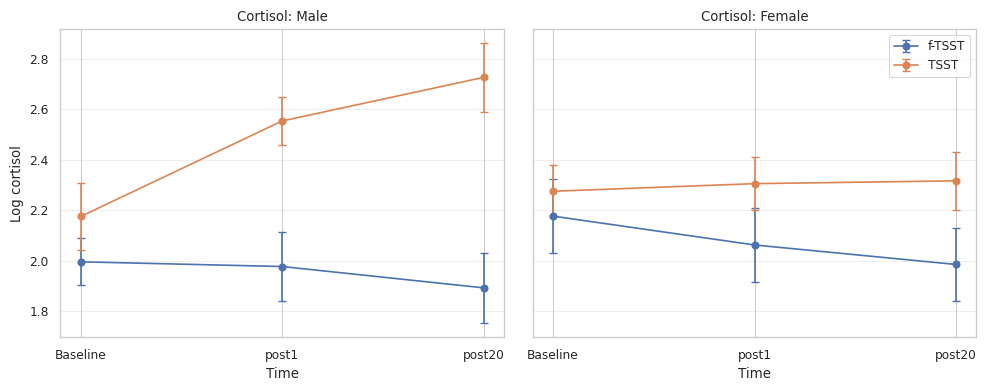

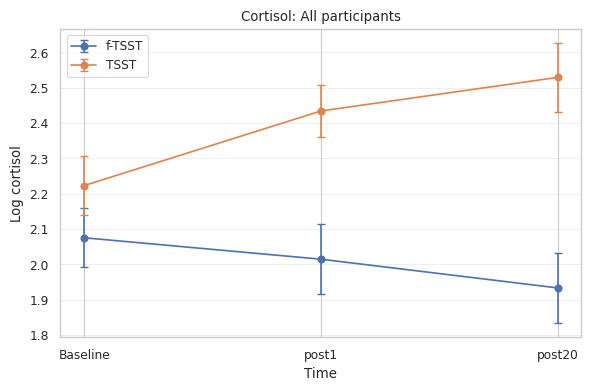

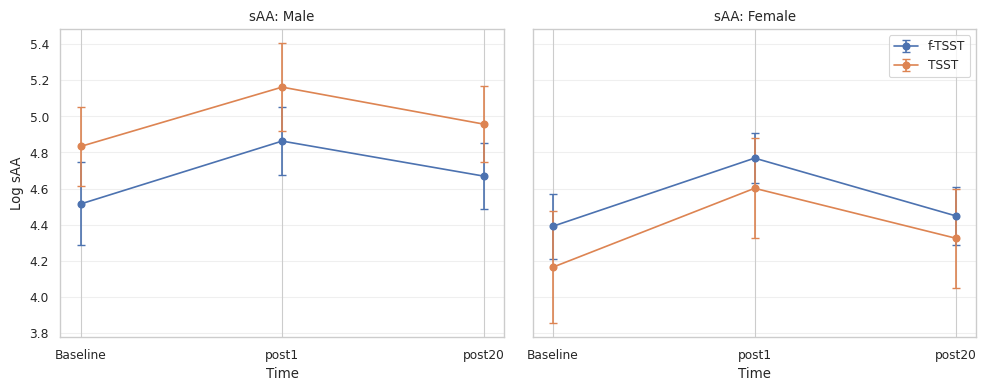

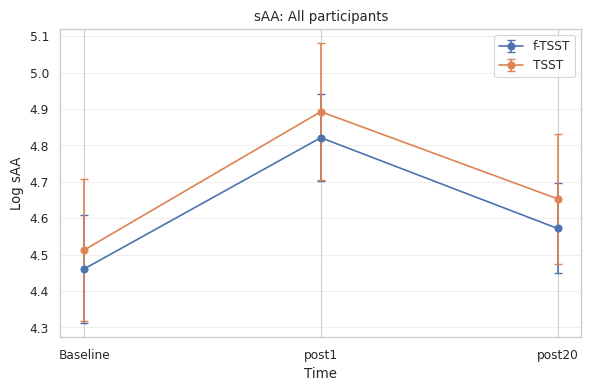

In [39]:
# graphs for the time course of cortisol and sAA (LN)

def _make_long(df, value_cols, value_name):
    long = pd.melt(
        df,
        id_vars=["vpn", "Cond", "Sex"],
        value_vars=value_cols,
        var_name="Time",
        value_name=value_name
    )

    time_map = {
        value_cols[0]: "Baseline",
        value_cols[1]: "post1",
        value_cols[2]: "post20",
    }
    long["Time"] = long["Time"].map(time_map)
    long["Time"] = pd.Categorical(long["Time"], categories=["Baseline", "post1", "post20"], ordered=True)
    return long

def _summarize(long, ycol):
    g = long.groupby(["Sex", "Cond", "Time"])[ycol]
    summary = g.agg(mean="mean", sd="std", n="count").reset_index()
    summary["se"] = summary["sd"] / np.sqrt(summary["n"])
    return summary

def _summarize_pooled(long, ycol):
    g = long.groupby(["Cond", "Time"])[ycol]
    summary = g.agg(mean="mean", sd="std", n="count").reset_index()
    summary["se"] = summary["sd"] / np.sqrt(summary["n"])
    return summary

def plot_timecourse(summary, y_label, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    sex_label = {0: "Male", 1: "Female"}

    for ax, sex_val in zip(axes, [0, 1]):
        sub = summary[summary["Sex"] == sex_val].copy()

        for cond_val, cond_name in [(0, "f-TSST"), (1, "TSST")]:
            s = sub[sub["Cond"] == cond_val].sort_values("Time")
            ax.errorbar(
                s["Time"].astype(str),
                s["mean"],
                yerr=s["se"],
                marker="o",
                capsize=3,
                label=cond_name
            )

        ax.set_title(f"{title_prefix}{sex_label[sex_val]}")
        ax.set_xlabel("Time")
        ax.grid(True, axis="y", alpha=0.3)

    axes[0].set_ylabel(y_label)
    axes[1].legend(loc="best")

    fig.tight_layout()
    plt.show()

def plot_timecourse_pooled(summary, y_label, title_prefix=""):
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    for cond_val, cond_name in [(0, "f-TSST"), (1, "TSST")]:
        s = summary[summary["Cond"] == cond_val].sort_values("Time")
        ax.errorbar(
            s["Time"].astype(str),
            s["mean"],
            yerr=s["se"],
            marker="o",
            capsize=3,
            label=cond_name
        )

    ax.set_title(f"{title_prefix}All participants")
    ax.set_xlabel("Time")
    ax.set_ylabel(y_label)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="best")

    fig.tight_layout()
    plt.show()

# Log cortisol
cort_long = _make_long(df, ["LNCortisol_BL", "LNCortisol_post1", "LNCortisol_post20"], "LNCortisol")
cort_sum = _summarize(cort_long, "LNCortisol")
plot_timecourse(cort_sum, y_label="Log cortisol", title_prefix="Cortisol: ")

cort_sum_pooled = _summarize_pooled(cort_long, "LNCortisol")
plot_timecourse_pooled(cort_sum_pooled, y_label="Log cortisol", title_prefix="Cortisol: ")

# Log sAA
saa_long = _make_long(df, ["LNsAA_BL", "LNsAA_post1", "LNsAA_post20"], "LNsAA")
saa_sum = _summarize(saa_long, "LNsAA")
plot_timecourse(saa_sum, y_label="Log sAA", title_prefix="sAA: ")

saa_sum_pooled = _summarize_pooled(saa_long, "LNsAA")
plot_timecourse_pooled(saa_sum_pooled, y_label="Log sAA", title_prefix="sAA: ")

Here we build the combined cortisol and sAA time-course figure (pooled across sex) and save it as PNG and PDF for the manuscript.

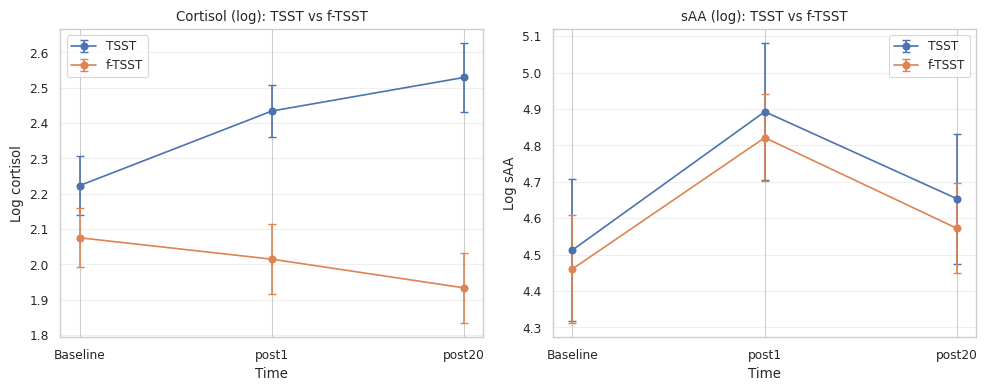

In [40]:
TIME_ORDER = ["Baseline", "post1", "post20"]

def _make_long(df, value_cols, value_name):
    long = pd.melt(
        df,
        id_vars=["vpn", "Cond", "Sex"],
        value_vars=value_cols,
        var_name="Time",
        value_name=value_name
    )
    time_map = {
        value_cols[0]: "Baseline",
        value_cols[1]: "post1",
        value_cols[2]: "post20",
    }
    long["Time"] = long["Time"].map(time_map)
    long["Time"] = pd.Categorical(long["Time"], categories=TIME_ORDER, ordered=True)
    return long

def _summarize_pooled(long, ycol):
    g = long.groupby(["Cond", "Time"])[ycol]
    summary = g.agg(mean="mean", sd="std", n="count").reset_index()
    summary["se"] = summary["sd"] / np.sqrt(summary["n"])
    return summary

def _plot_mean_se(ax, summary, y_label, title):
    for cond_val, cond_name in [(1, "TSST"), (0, "f-TSST")]: 
        s = summary[summary["Cond"] == cond_val].sort_values("Time")
        ax.errorbar(
            s["Time"].astype(str),
            s["mean"],
            yerr=s["se"],
            marker="o",
            capsize=3,
            label=cond_name
        )
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel(y_label)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="best")

def plot_timecourse(df):
    cort_long = _make_long(df, ["LNCortisol_BL","LNCortisol_post1","LNCortisol_post20"], "LNCortisol")
    saa_long  = _make_long(df, ["LNsAA_BL","LNsAA_post1","LNsAA_post20"], "LNsAA")

    cort_sum = _summarize_pooled(cort_long, "LNCortisol")
    saa_sum  = _summarize_pooled(saa_long,  "LNsAA")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    _plot_mean_se(axes[0], cort_sum, "Log cortisol", "Cortisol (log): TSST vs f-TSST")
    _plot_mean_se(axes[1], saa_sum,  "Log sAA",      "sAA (log): TSST vs f-TSST")
    fig.tight_layout()
    
    return fig

fig = plot_timecourse(df)
fig.savefig("biomarker_timecourse.png", dpi=300, bbox_inches="tight")
fig.savefig("biomarker_timecourse.pdf", bbox_inches="tight")
plt.show()

# Voice Analysis (Group Comparison)

### Descriptive Values

Here we compute the descriptive statistics (count, mean, std) of the main voice features by sex and condition.

In [41]:
col_of_interest=['agg_f0mean', 'meanF0Hz', 'stdevF0Hz', 'energy', 
                 'localJitter', 'localShimmer', 'HNR', 'median_pitch']

print (df.groupby(['Sex', 'Cond'])[col_of_interest].count())
print (df.groupby(['Sex', 'Cond'])[col_of_interest].mean())
print (df.groupby(['Sex', 'Cond'])[col_of_interest].std())

          agg_f0mean  meanF0Hz  stdevF0Hz  energy  localJitter  localShimmer  \
Sex Cond                                                                       
0   0             14        14         14      14           14            14   
    1             13        13         13      13           13            13   
1   0             11        11         11      11           11            11   
    1             12        12         12      12           12            12   

          HNR  median_pitch  
Sex Cond                     
0   0      14            14  
    1      13            13  
1   0      11            11  
    1      12            12  
          agg_f0mean    meanF0Hz  stdevF0Hz    energy  localJitter  \
Sex Cond                                                             
0   0     115.809331  115.083662  18.565955  0.038052     0.028508   
    1     121.176100  117.175700  18.355686  0.039822     0.028579   
1   0     199.299626  208.164109  40.305232  0.038624     0

### Statistical Tests of Group Differences (Voice Features)

Stressed (1) vs. Friendly (0) and Female (1) vs. Male (0)

First Check: MANOVA -> Are there any group differences?

Here we run a MANOVA over the core voice features to check whether there are any overall group differences before looking at single features.

In [42]:
maov = MANOVA.from_formula('meanF0Hz + stdevF0Hz + HNR + localShimmer + localJitter + energy ~ Cond + Sex + Cond:Sex', data=df)
print(maov.mv_test())

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value   Num DF  Den DF  F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda   0.0020 6.0000 41.0000 3335.9155 0.0000
         Pillai's trace   0.9980 6.0000 41.0000 3335.9155 0.0000
 Hotelling-Lawley trace 488.1828 6.0000 41.0000 3335.9155 0.0000
    Roy's greatest root 488.1828 6.0000 41.0000 3335.9155 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
              Cond          Value  Num DF  Den DF F Value Pr > F
----------------------------------------------------------------
              Wilks' lambda 0.6693 6.0000 41.0000  3.3766 0.0085
             Pillai's trace 0.3307 6.0000 41.

## Microvariation: Shimmer & Jitter

OLS model of local jitter, including the Condition × Sex interaction.

In [44]:
formula = 'localJitter ~  C(Cond)* C(Sex)'
model = ols(formula, df).fit()
print (model.summary())

                            OLS Regression Results                            
Dep. Variable:            localJitter   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     7.890
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           0.000238
Time:                        11:29:57   Log-Likelihood:                 206.82
No. Observations:                  50   AIC:                            -405.6
Df Residuals:                      46   BIC:                            -398.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

swarm-plot of local jitter.

/tmp/ipykernel_2963108/3290753908.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  ax = sns.boxplot(x=group, y=dv, data=df, hue='Cond', showfliers = False, color='grey')


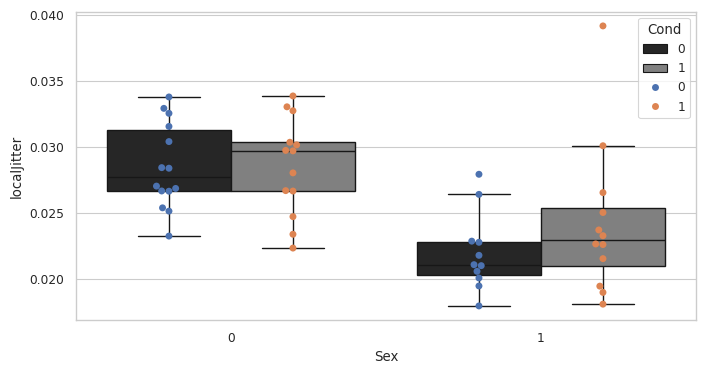

In [45]:
swarm_dualplot(df, 'localJitter', 'Sex', 'Cond', 'localJitter')

OLS model of local shimmer (cycle-to-cycle amplitude variation), including the interaction.

In [46]:
formula = 'localShimmer ~  C(Cond) * C(Sex)'
model = ols(formula, df).fit()
print (model.summary())

                            OLS Regression Results                            
Dep. Variable:           localShimmer   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     25.44
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           7.47e-10
Time:                        11:29:59   Log-Likelihood:                 168.44
No. Observations:                  50   AIC:                            -328.9
Df Residuals:                      46   BIC:                            -321.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

swarm-plot of local shimmer.

/tmp/ipykernel_2963108/3290753908.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  ax = sns.boxplot(x=group, y=dv, data=df, hue='Cond', showfliers = False, color='grey')


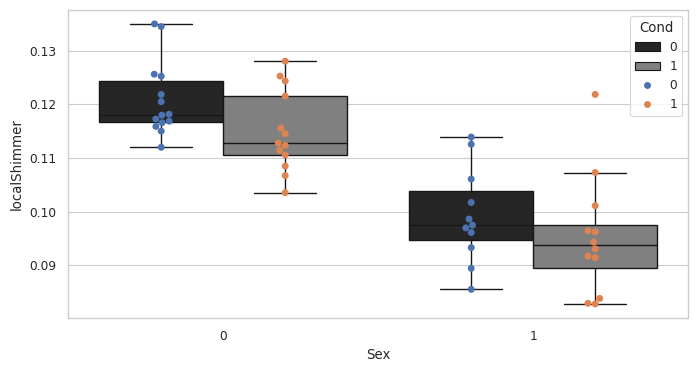

In [47]:
swarm_dualplot(df, 'localShimmer', 'Sex', 'Cond', 'localShimmer')

## Energy

Box-plot of vocal energy by condition.

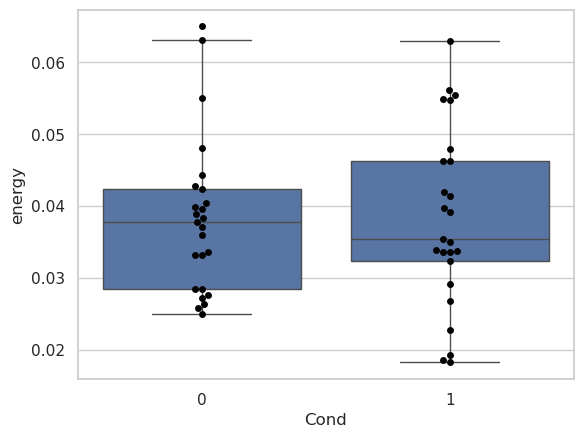

In [48]:
import mystats
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()
sns.set(style="whitegrid")
ax = sns.boxplot(x="Cond", y="energy", data=df, showfliers = False)
sns.swarmplot(x="Cond", y="energy", data=df, color=".01", ax=ax)
plt.show()



OLS model of vocal energy.

In [49]:
formula = 'energy ~ C(Cond)+C(Sex)'
model = ols(formula, df).fit()
print (model.summary())

                            OLS Regression Results                            
Dep. Variable:                 energy   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.040
Method:                 Least Squares   F-statistic:                   0.06699
Date:                Sat, 20 Jun 2026   Prob (F-statistic):              0.935
Time:                        11:30:00   Log-Likelihood:                 152.66
No. Observations:                  50   AIC:                            -299.3
Df Residuals:                      47   BIC:                            -293.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0388      0.003     13.979   

## Harmony-To-Noise Ratio (HNR)

OLS model of the harmonics-to-noise ratio (HNR).

In [50]:
formula = 'HNR ~ C(Sex)+C(Cond)'
model = ols(formula, df).fit()
print (model.summary())

                            OLS Regression Results                            
Dep. Variable:                    HNR   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     22.35
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           1.51e-07
Time:                        11:30:00   Log-Likelihood:                -90.839
No. Observations:                  50   AIC:                             187.7
Df Residuals:                      47   BIC:                             193.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0347      0.362     35.999   

Same model additionally controlling for the cortisol change (`Delta_LNCort`).

In [51]:
formula = 'HNR ~ C(Sex)+C(Cond)+Delta_LNCort'
model = ols(formula, df).fit()
print (model.summary())

                            OLS Regression Results                            
Dep. Variable:                    HNR   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     15.61
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           3.86e-07
Time:                        11:30:00   Log-Likelihood:                -89.993
No. Observations:                  50   AIC:                             188.0
Df Residuals:                      46   BIC:                             195.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0283      0.360     36.201   

Swarm-plot of HNR.

/tmp/ipykernel_2963108/3290753908.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  ax = sns.boxplot(x=group, y=dv, data=df, hue='Cond', showfliers = False, color='grey')


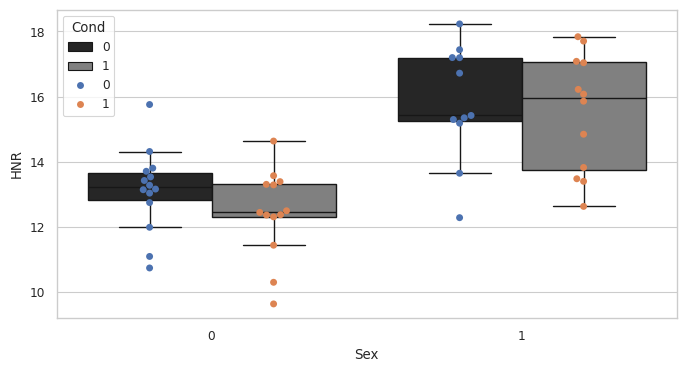

In [52]:
swarm_dualplot(df, 'HNR', 'Sex', 'Cond', 'HNR')

# Time of Speaking (Audio lengths)

In [53]:
# descriptives for length distributions before and after processing/cutting

Here we model the speaking length (number of frames) with an OLS model and additional two-sample tests by condition and sex.

In [54]:
import mystats
formula = 'length ~ C(Cond)+C(Sex)'

model = ols(formula, df).fit()
print (model.summary())
mystats.two_ind_sample_tests(df[df.Cond==0], df[df.Cond==1], 'length')

                            OLS Regression Results                            
Dep. Variable:                 length   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     17.18
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           2.51e-06
Time:                        11:30:02   Log-Likelihood:                -481.53
No. Observations:                  50   AIC:                             969.1
Df Residuals:                      47   BIC:                             974.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.622e+04    896.018     18.100   

Descriptive statistics of the speaking length per condition.

In [55]:
# Mean and SD of length per condition for PROCESSED audio
df.groupby("Cond")["length"].agg(["count", "mean", "std", "min", "median", "max"])

,count,mean,std,min,median,max
Cond,,,,,,
0,25,16815.08,2536.141868,10246.0,16786.0,21444.0
1,25,10662.72,4773.933367,2826.0,10212.0,19728.0


Here we convert the speaking length from librosa frames into seconds and minutes (sr = 22050, hop_length = 512).

In [56]:
# Convert length into seconds/minutes
sr = 22050        # default librosa
hop_length = 512  # default librosa

hop_s = hop_length / sr

# Original (frames)
len_frames = df.groupby("Cond")["length"].agg(["count", "mean", "std", "min", "median", "max"])

# Converted to seconds
len_seconds = len_frames.copy()
for c in ["mean", "std", "min", "median", "max"]:
    len_seconds[c] = len_seconds[c] * hop_s

# Converted to minutes
len_minutes = len_seconds.copy()
for c in ["mean", "std", "min", "median", "max"]:
    len_minutes[c] = len_minutes[c] / 60


len_frames.index.name = "Cond"
len_seconds.index.name = "Cond"
len_minutes.index.name = "Cond"

print("Length in frames (as stored):")
display(len_frames)

print(f"\nLength converted to seconds (sr={sr}, hop_length={hop_length}, hop_s={hop_s:.6f}):")
display(len_seconds)

print("\nLength converted to minutes:")
display(len_minutes)

Length in frames (as stored):


,count,mean,std,min,median,max
Cond,,,,,,
0,25,16815.08,2536.141868,10246.0,16786.0,21444.0
1,25,10662.72,4773.933367,2826.0,10212.0,19728.0



Length converted to seconds (sr=22050, hop_length=512, hop_s=0.023220):


,count,mean,std,min,median,max
Cond,,,,,,
0,25,390.445395,58.889099,237.911655,389.770159,497.928707
1,25,247.587875,110.850516,65.619592,237.122177,458.083265



Length converted to minutes:


,count,mean,std,min,median,max
Cond,,,,,,
0,25,6.507423,0.981485,3.965194,6.496169,8.298812
1,25,4.126465,1.847509,1.093660,3.952036,7.634721


swarm-plot of the speaking length by condition.

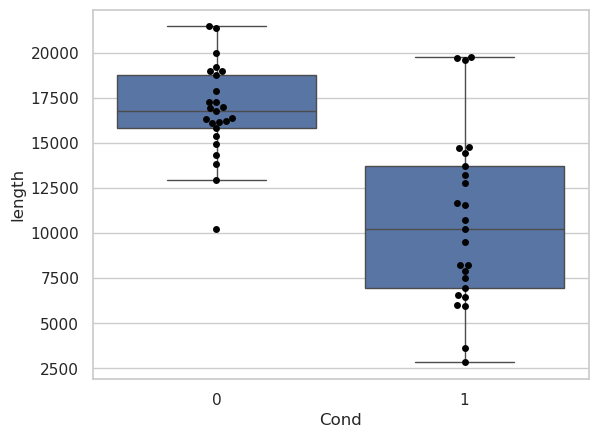

In [57]:
plt.figure()
sns.set(style="whitegrid")

ax = sns.boxplot(x="Cond", y="length", data=df, showfliers = False)
sns.swarmplot(x="Cond", y="length", data=df, color=".01", ax=ax)

plt.show()

https://github.com/drfeinberg/PraatScripts

Correlation matrix between the micro-variation features, the cortisol reaction and negative affect. Note: frequency features should be analysed separately for men and women.

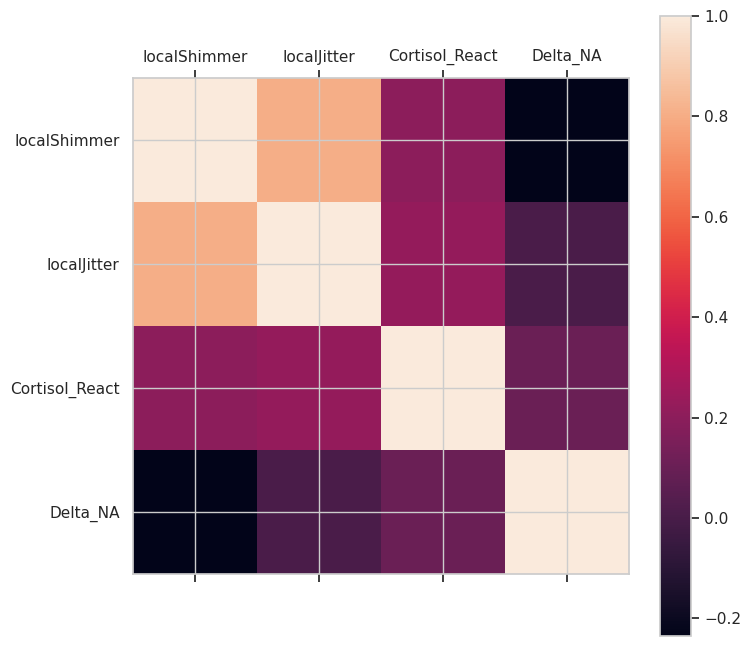

In [58]:
# für die Stressgruppe (?): Zusammenhänge von Cortisolanstieg und Stimmung mit den Stimmparametern
# Achtung: für Frequenzwerte muss nach Männern und Frauen getrennt werden
rcParams['figure.figsize'] = 10, 8
audio_gender=['meanF0Hz', 'stdevF0Hz', 'engergy']
audio_small=['localShimmer', 'localJitter', 'Cortisol_React', 'Delta_NA']
plt.matshow(df[audio_small].corr())
plt.xticks(np.arange(df[audio_small].shape[1]), df[audio_small].columns)
plt.yticks(np.arange(df[audio_small].shape[1]), df[audio_small].columns)
#ax = sns.heatmap(df_vpn[audio_small].corr(), vmin=0, vmax=1)
plt.colorbar()
plt.show()

Here we inspect the distribution of the speaking length: a histogram overall, a histogram split by condition and the cumulative distribution (ECDF) by condition.

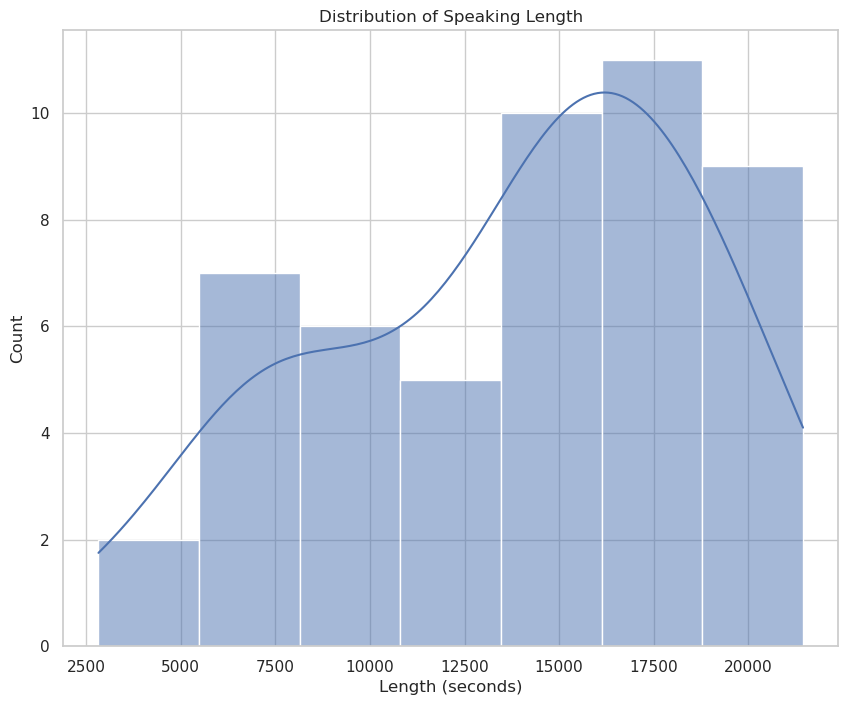

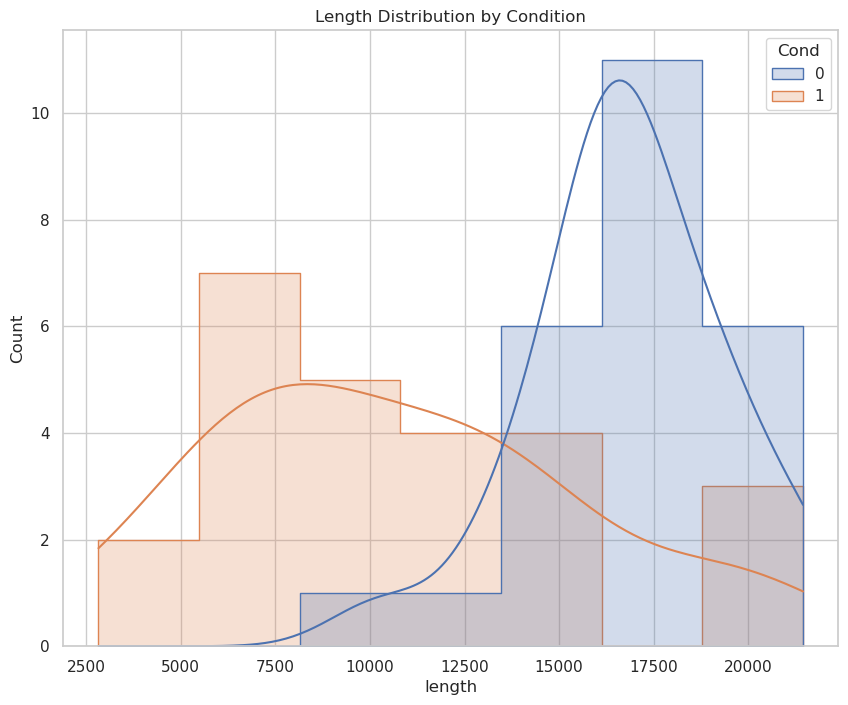

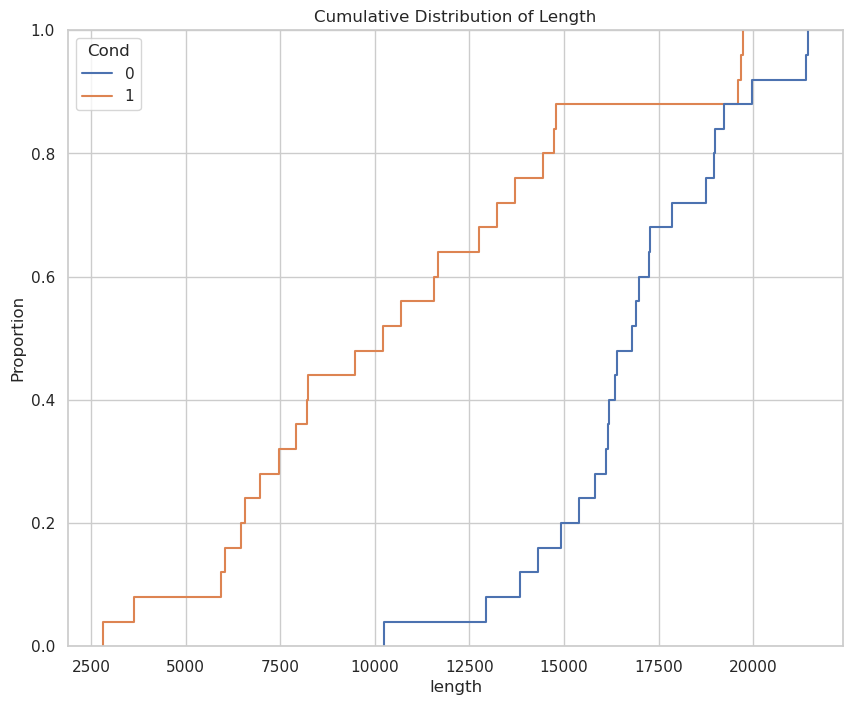

In [59]:
df.groupby(["Cond", "Sex"])["length"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    p10=lambda x: np.percentile(x, 10),
    p25=lambda x: np.percentile(x, 25),
    p75=lambda x: np.percentile(x, 75),
    p90=lambda x: np.percentile(x, 90),
    max="max"
)

sns.histplot(df["length"], kde=True)
plt.title("Distribution of Speaking Length")
plt.xlabel("Length (seconds)")
plt.ylabel("Count")
plt.show()

sns.histplot(data=df, x="length", hue="Cond", kde=True, element="step")
plt.title("Length Distribution by Condition")
plt.show()

sns.ecdfplot(data=df, x="length", hue="Cond")
plt.title("Cumulative Distribution of Length")
plt.show()

### Graphics

/tmp/ipykernel_2963108/3290753908.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  ax = sns.boxplot(x=group, y=dv, data=df, hue='Cond', showfliers = False, color='grey')


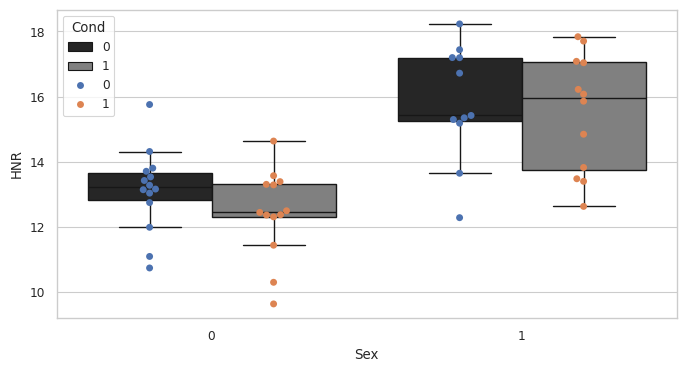

In [60]:
swarm_dualplot(df, 'HNR', 'Sex', 'Cond', 'Figure1')

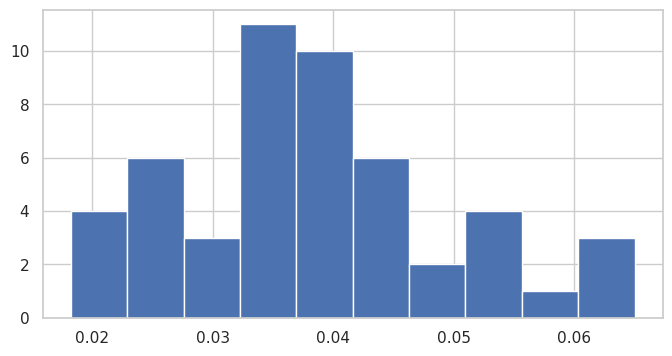

In [61]:
plt.figure(figsize=(8,4))
sns.set(style="whitegrid")
plt.hist(df.energy)
plt.show()

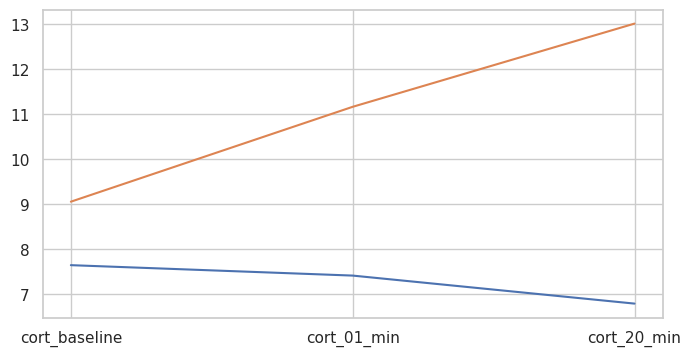

In [62]:
plt.figure(figsize=(8,4))
sns.set(style="whitegrid")
#plt.plot(df.groupby('Cond').mean()[['cort_baseline', 'cort_01_min', 'cort_20_min']].T)
plt.plot(
    df.groupby('Cond')[['cort_baseline', 'cort_01_min', 'cort_20_min']]
      .mean()
      .T
)

plt.show()

In [63]:
#df.groupby('Cond').mean()[['cort_baseline', 'cort_01_min', 'cort_20_min']]
df.groupby("Cond")[["cort_baseline", "cort_01_min", "cort_20_min"]].mean()


,cort_baseline,cort_01_min,cort_20_min
Cond,,,
0,7.644818,7.412959,6.789896
1,9.056552,11.166781,13.017200
